<a href="https://colab.research.google.com/github/Andrew-lee0615/Quant-Strategies/blob/main/Strategy_02_BITCOIN_Crossover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_7634/1774706625.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')
[*********************100%***********************]  1 of 1 completed


--- BTC-USD 10Y Trend-Following Report ---
Initial Investment: $100,000
Final Value: $11,069,450.46
Total Return: 10969.45%
CAGR: 60.11%
Max Drawdown (MDD): -54.10%


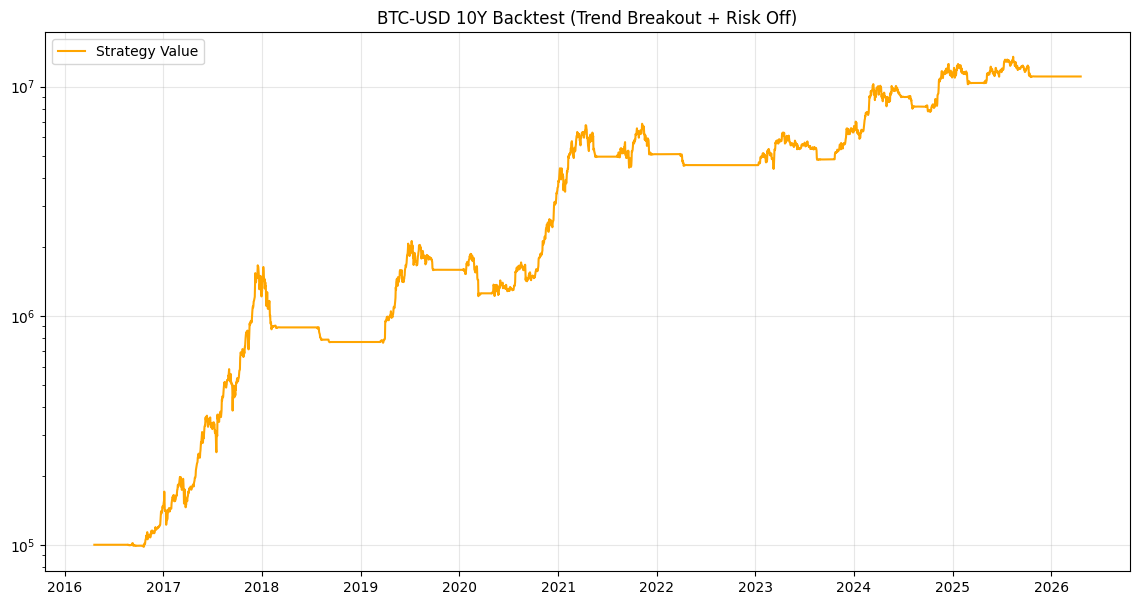

In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Retrieval
ticker = 'BTC-USD'
df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')

# 2. Indicators
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()
df['MA120'] = df['Close'].rolling(window=120).mean()

# 3. Variables
initial_cash = 100000
cash = initial_cash
shares = 0
portfolio_values = []

# 4. Simulation Loop
for i in range(len(df)):
    price = df['Close'].iloc[i]
    ma10, ma20, ma60, ma120 = df['MA10'].iloc[i], df['MA20'].iloc[i], df['MA60'].iloc[i], df['MA120'].iloc[i]

    if pd.isna(ma120):
        portfolio_values.append(initial_cash)
        continue

    # --- [STRATEGY LOGIC] ---

    # A. Trend Breakout Buy (Price > MA120 * 1.02)
    if price >= ma120 * 1.02 and cash > 0:
        buy_amt = cash * 0.20
        shares += buy_amt / price
        cash -= buy_amt

    # B. Standard Buy (Only when above MA120)
    elif price > ma120:
        buy_pct = 0
        if price <= ma60:
            buy_pct = 0.10
        elif price <= ma20:
            buy_pct = 0.05

        if buy_pct > 0 and cash > 0:
            buy_amt = cash * buy_pct
            shares += buy_amt / price
            cash -= buy_amt

    # C. Profit Taking (Aggressive: Price > MA10 * 1.08)
    if price >= ma10 * 1.08 and shares > 0:
        sell_shares = shares * 0.15
        cash += sell_shares * price
        shares -= sell_shares

    # D. Risk Off (Exit when below MA120)
    if price < ma120 and shares > 0:
        sell_shares = shares * 0.20
        cash += sell_shares * price
        shares -= sell_shares

    portfolio_values.append((shares * price) + cash)

df['Portfolio_Value'] = portfolio_values

# 5. Performance Metrics
df['Peak'] = df['Portfolio_Value'].cummax()
df['Drawdown'] = (df['Portfolio_Value'] - df['Peak']) / df['Peak']
final_mdd = df['Drawdown'].min() * 100
final_val = df['Portfolio_Value'].iloc[-1]
total_return = ((final_val - initial_cash) / initial_cash) * 100
cagr = (((final_val / initial_cash) ** (1/10)) - 1) * 100

# 6. Report
print(f"--- {ticker} 10Y Trend-Following Report ---")
print(f"Initial Investment: ${initial_cash:,.0f}")
print(f"Final Value: ${final_val:,.2f}")
print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")
print(f"Max Drawdown (MDD): {final_mdd:.2f}%")

# Plot
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Portfolio_Value'], color='orange', label='Strategy Value')
plt.title(f'{ticker} 10Y Backtest (Trend Breakout + Risk Off)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_7634/3946489095.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')
[*********************100%***********************]  1 of 1 completed


--- BTC-USD Aggressive Risk-Off Report ---
Initial Investment: $100,000
Final Value: $15,273,564.84
Total Return: 15173.56%
CAGR: 65.35%
Max Drawdown (MDD): -48.46%


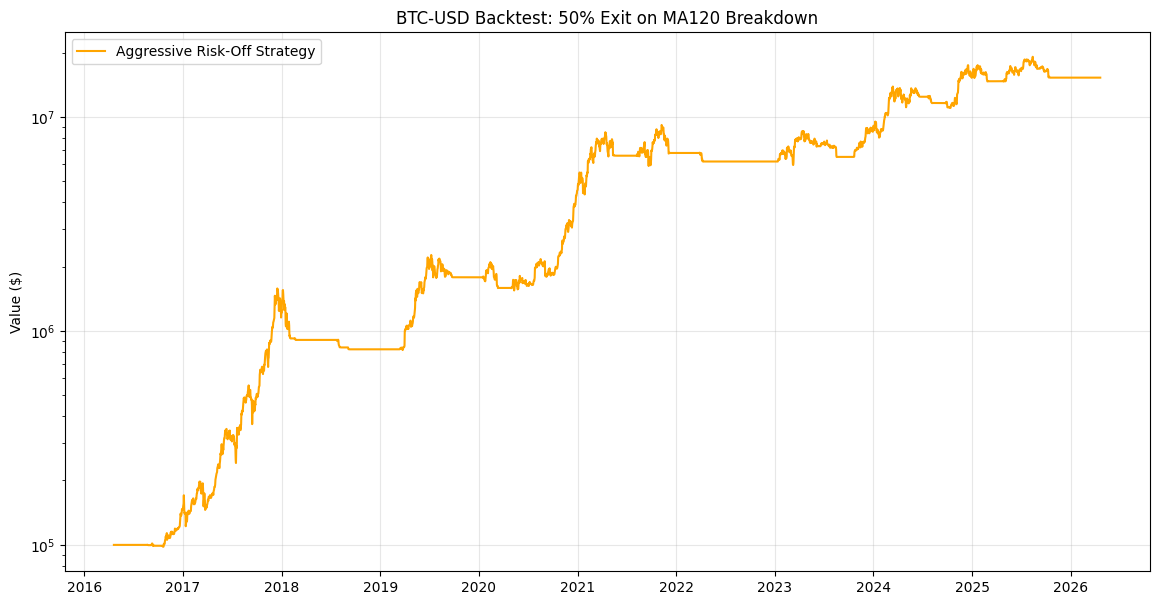

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Retrieval
ticker = 'BTC-USD'
df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')

# 2. Indicators
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()
df['MA120'] = df['Close'].rolling(window=120).mean()

# 3. Variables
initial_cash = 100000
cash = initial_cash
shares = 0
portfolio_values = []

# 4. Simulation Loop
for i in range(len(df)):
    price = df['Close'].iloc[i]
    ma10, ma20, ma60, ma120 = df['MA10'].iloc[i], df['MA20'].iloc[i], df['MA60'].iloc[i], df['MA120'].iloc[i]

    if pd.isna(ma120):
        portfolio_values.append(initial_cash)
        continue

    # --- [STRATEGY LOGIC] ---

    # A. Trend Breakout Buy (Confirming upward trend)
    if price >= ma120 * 1.02 and cash > 0:
        buy_amt = cash * 0.20
        shares += buy_amt / price
        cash -= buy_amt

    # B. Standard Buy (Strictly ONLY when above MA120)
    elif price > ma120:
        buy_pct = 0
        if price <= ma60:
            buy_pct = 0.10
        elif price <= ma20:
            buy_pct = 0.05

        if buy_pct > 0 and cash > 0:
            buy_amt = cash * buy_pct
            shares += buy_amt / price
            cash -= buy_amt

    # C. Aggressive Profit Taking (Price > MA10 * 1.08)
    if price >= ma10 * 1.08 and shares > 0:
        sell_shares = shares * 0.15
        cash += sell_shares * price
        shares -= sell_shares

    # D. STRONG RISK-OFF (Exit 50% when below MA120)
    if price < ma120 and shares > 0:
        sell_shares = shares * 0.50 # Upgraded from 20% to 50%
        cash += sell_shares * price
        shares -= sell_shares

    portfolio_values.append((shares * price) + cash)

df['Portfolio_Value'] = portfolio_values

# 5. Performance Metrics
df['Peak'] = df['Portfolio_Value'].cummax()
df['Drawdown'] = (df['Portfolio_Value'] - df['Peak']) / df['Peak']
final_mdd = df['Drawdown'].min() * 100
final_val = df['Portfolio_Value'].iloc[-1]
total_return = ((final_val - initial_cash) / initial_cash) * 100
cagr = (((final_val / initial_cash) ** (1/10)) - 1) * 100

# 6. Report
print(f"--- {ticker} Aggressive Risk-Off Report ---")
print(f"Initial Investment: ${initial_cash:,.0f}")
print(f"Final Value: ${final_val:,.2f}")
print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")
print(f"Max Drawdown (MDD): {final_mdd:.2f}%")

# Plot
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Portfolio_Value'], color='orange', label='Aggressive Risk-Off Strategy')
plt.title(f'{ticker} Backtest: 50% Exit on MA120 Breakdown')
plt.yscale('log')
plt.ylabel('Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_7634/1981922332.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')
[*********************100%***********************]  1 of 1 completed


--- BTC-USD MDD Optimized Report ---
Total Return: 16086.24%
CAGR: 66.31%
Max Drawdown (MDD): -48.05%
Final Value: $16,186,240.09


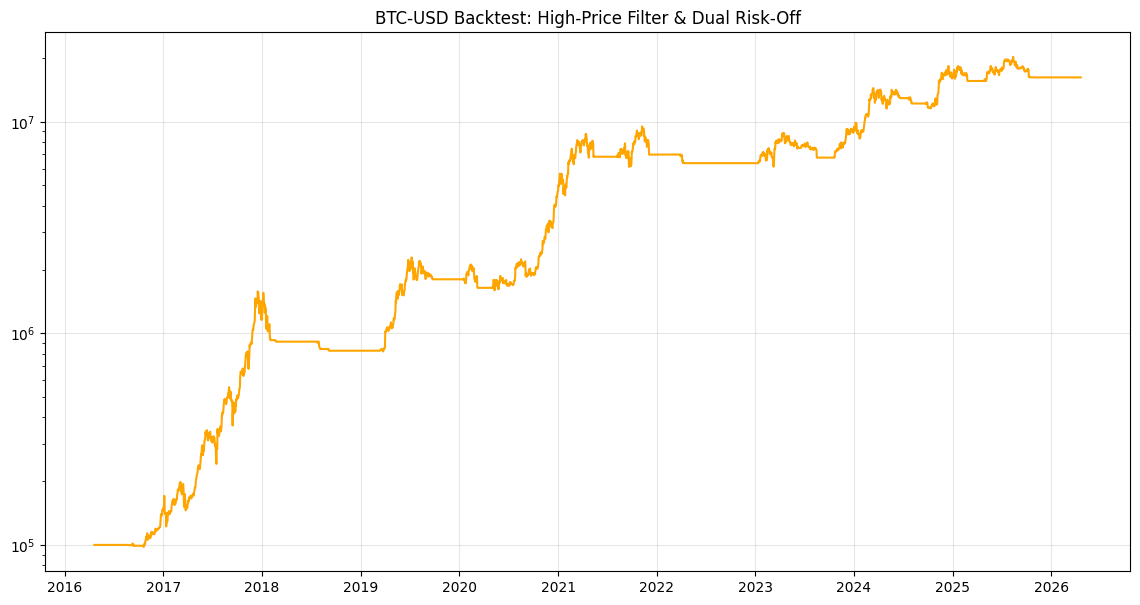

In [9]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Retrieval
ticker = 'BTC-USD'
df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')

# 2. Indicators
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()
df['MA120'] = df['Close'].rolling(window=120).mean()

# 3. Variables
initial_cash = 100000
cash = initial_cash
shares = 0
portfolio_values = []

# 4. Simulation Loop
for i in range(len(df)):
    price = df['Close'].iloc[i]
    ma10, ma20, ma60, ma120 = df['MA10'].iloc[i], df['MA20'].iloc[i], df['MA60'].iloc[i], df['MA120'].iloc[i]

    if pd.isna(ma120):
        portfolio_values.append(initial_cash)
        continue

    # --- [STRATEGY LOGIC: MDD OPTIMIZED] ---

    # Check for Overbought State (Is price too far from long-term mean?)
    is_overbought = price > ma120 * 1.60

    # A. Trend Breakout Buy (Confirming upward trend)
    if price >= ma120 * 1.02 and cash > 0:
        buy_amt = cash * 0.20
        shares += buy_amt / price
        cash -= buy_amt

    # B. Standard Buy (Only when NOT overbought)
    elif price > ma120 and not is_overbought:
        buy_pct = 0
        if price <= ma60:
            buy_pct = 0.10
        elif price <= ma20:
            buy_pct = 0.05

        if buy_pct > 0 and cash > 0:
            buy_amt = cash * buy_pct
            shares += buy_amt / price
            cash -= buy_amt

    # C. Aggressive Profit Taking (Price > MA10 * 1.08)
    if price >= ma10 * 1.08 and shares > 0:
        sell_shares = shares * 0.15
        cash += sell_shares * price
        shares -= sell_shares

    # D. DUAL RISK-OFF (Aggressive Exit)
    # 1. Immediate 50% Sell on MA120 Break
    if price < ma120 and shares > 0:
        # 2. Total Exit if price stays below or drops further (e.g., MA120 * 0.95)
        if price < ma120 * 0.95:
            sell_shares = shares # Exit All
        else:
            sell_shares = shares * 0.50 # Half Exit

        cash += sell_shares * price
        shares -= sell_shares

    portfolio_values.append((shares * price) + cash)

df['Portfolio_Value'] = portfolio_values

# 5. Performance Metrics
df['Peak'] = df['Portfolio_Value'].cummax()
df['Drawdown'] = (df['Portfolio_Value'] - df['Peak']) / df['Peak']
final_mdd = df['Drawdown'].min() * 100
final_val = df['Portfolio_Value'].iloc[-1]
total_return = ((final_val - initial_cash) / initial_cash) * 100
cagr = (((final_val / initial_cash) ** (1/10)) - 1) * 100

# 6. Report
print(f"--- {ticker} MDD Optimized Report ---")
print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")
print(f"Max Drawdown (MDD): {final_mdd:.2f}%")
print(f"Final Value: ${final_val:,.2f}")

# Plot
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Portfolio_Value'], color='orange')
plt.title(f'{ticker} Backtest: High-Price Filter & Dual Risk-Off')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_7634/148261391.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')
[*********************100%***********************]  1 of 1 completed


--- BTC-USD Final Optimized Report ---
Total Return: 15751.43%
CAGR: 65.96%
Max Drawdown (MDD): -43.91%
Final Value: $15,851,429.31


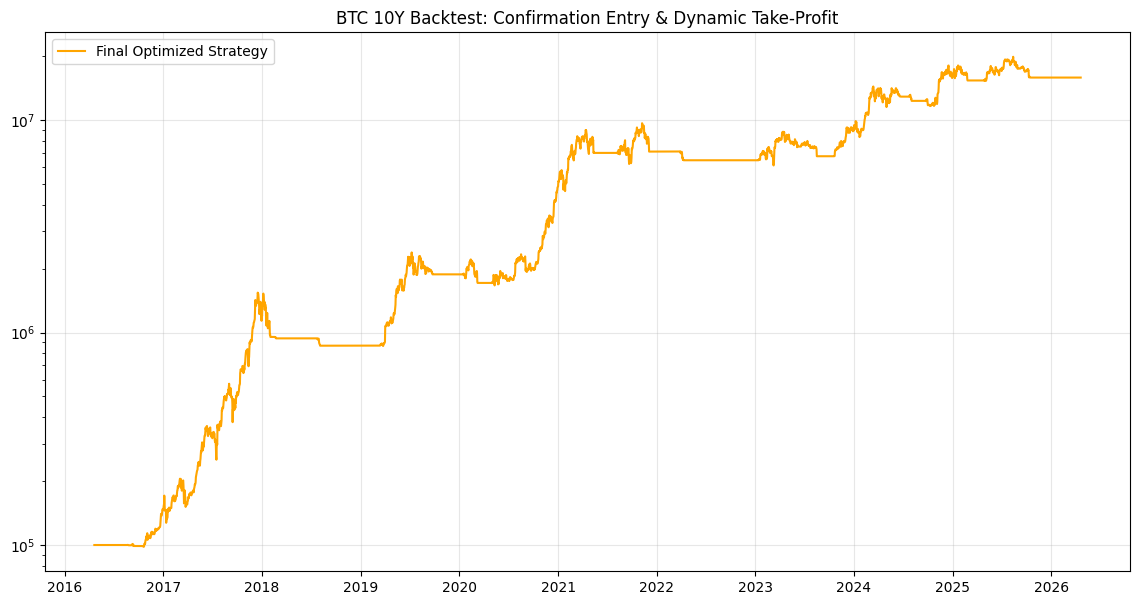

In [10]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Retrieval
ticker = 'BTC-USD'
df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')

# 2. Indicators
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()
df['MA120'] = df['Close'].rolling(window=120).mean()

# 3. Confirmation Logic Helper: Check if price stayed above MA120 for 5 days
df['Above_MA120'] = df['Close'] > df['MA120']
df['MA120_5d_streak'] = df['Above_MA120'].rolling(window=5).sum() == 5

# 4. Variables
initial_cash = 100000
cash = initial_cash
shares = 0
portfolio_values = []

# 5. Simulation Loop
for i in range(len(df)):
    price = df['Close'].iloc[i]
    ma10, ma20, ma60, ma120 = df['MA10'].iloc[i], df['MA20'].iloc[i], df['MA60'].iloc[i], df['MA120'].iloc[i]
    streak_5d = df['MA120_5d_streak'].iloc[i]

    if pd.isna(ma120):
        portfolio_values.append(initial_cash)
        continue

    # --- [STRATEGY LOGIC: ADVANCED OPTIMIZATION] ---

    # Check for Overbought State
    is_overbought = price > ma120 * 1.60

    # A. Confirmation Entry (Stronger filter)
    # Price > MA120 * 1.05 OR Price stayed above MA120 for 5 days
    if (price >= ma120 * 1.05 or streak_5d) and cash > 0:
        buy_amt = cash * 0.20
        shares += buy_amt / price
        cash -= buy_amt

    # B. Standard Buy (Only when NOT overbought)
    elif price > ma120 and not is_overbought:
        buy_pct = 0
        if price <= ma60: buy_pct = 0.10
        elif price <= ma20: buy_pct = 0.05
        if buy_pct > 0 and cash > 0:
            buy_amt = cash * buy_pct
            shares += buy_amt / price
            cash -= buy_amt

    # C. Dynamic Profit Taking (Two-tier)
    if shares > 0:
        if price >= ma10 * 1.15: # Extreme Overheat
            sell_shares = shares * 0.30
            cash += sell_shares * price
            shares -= sell_shares
        elif price >= ma10 * 1.08: # Normal Overheat
            sell_shares = shares * 0.15
            cash += sell_shares * price
            shares -= sell_shares

    # D. Dual Risk-Off (Exit Strategy)
    if price < ma120 and shares > 0:
        if price < ma120 * 0.95:
            sell_shares = shares # Final Exit
        else:
            sell_shares = shares * 0.50 # Initial Exit

        cash += sell_shares * price
        shares -= sell_shares

    portfolio_values.append((shares * price) + cash)

df['Portfolio_Value'] = portfolio_values

# 6. Performance Metrics
df['Peak'] = df['Portfolio_Value'].cummax()
df['Drawdown'] = (df['Portfolio_Value'] - df['Peak']) / df['Peak']
final_mdd = df['Drawdown'].min() * 100
final_val = df['Portfolio_Value'].iloc[-1]
total_return = ((final_val - initial_cash) / initial_cash) * 100
cagr = (((final_val / initial_cash) ** (1/10)) - 1) * 100

# 7. Report
print(f"--- BTC-USD Final Optimized Report ---")
print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")
print(f"Max Drawdown (MDD): {final_mdd:.2f}%")
print(f"Final Value: ${final_val:,.2f}")

# Plot
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Portfolio_Value'], color='orange', label='Final Optimized Strategy')
plt.title('BTC 10Y Backtest: Confirmation Entry & Dynamic Take-Profit')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

/tmp/ipykernel_7634/3369292722.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')
[*********************100%***********************]  1 of 1 completed


--- BTC-USD 30% MDD Challenge Report ---
Total Return: 10600.03%
CAGR: 59.57%
Max Drawdown (MDD): -36.91%
Final Value: $10,700,028.63


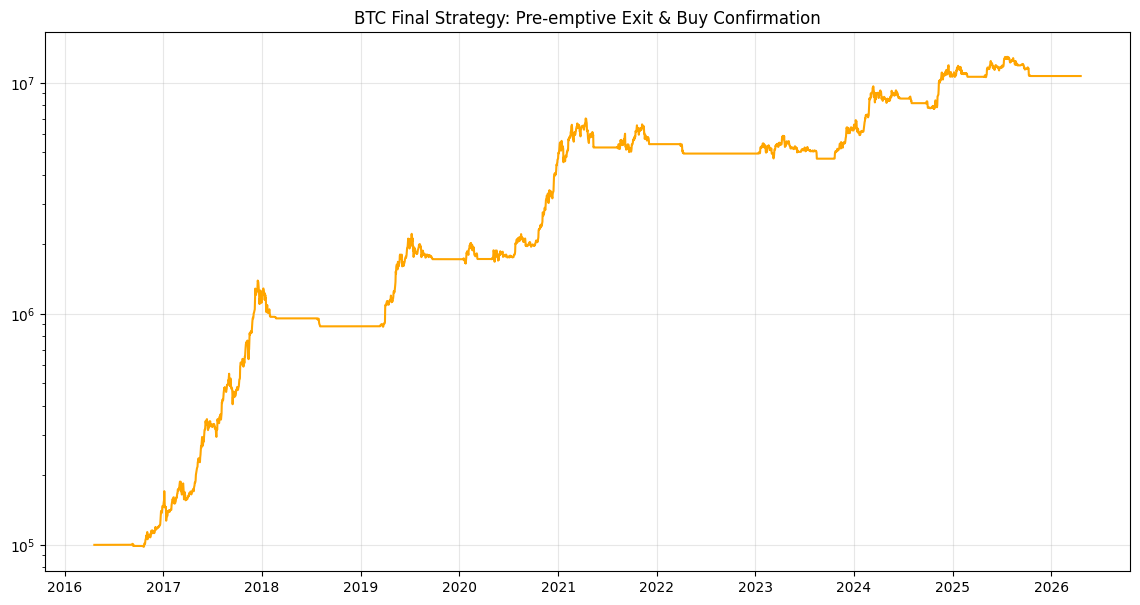

In [11]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Retrieval
ticker = 'BTC-USD'
df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')

# 2. Indicators
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()
df['MA120'] = df['Close'].rolling(window=120).mean()

# 3. Confirmation Logic
df['Above_MA120'] = df['Close'] > df['MA120']
df['MA120_5d_streak'] = df['Above_MA120'].rolling(window=5).sum() == 5
df['Is_Rising'] = df['Close'] > df['Close'].shift(1) # For confirmation buy

# 4. Variables
initial_cash = 100000
cash = initial_cash
shares = 0
portfolio_values = []

# 5. Simulation Loop
for i in range(len(df)):
    if i < 1:
        portfolio_values.append(initial_cash)
        continue

    price = df['Close'].iloc[i]
    ma10, ma20, ma60, ma120 = df['MA10'].iloc[i], df['MA20'].iloc[i], df['MA60'].iloc[i], df['MA120'].iloc[i]
    streak_5d = df['MA120_5d_streak'].iloc[i]
    is_rising = df['Is_Rising'].iloc[i]

    if pd.isna(ma120):
        portfolio_values.append(initial_cash)
        continue

    # --- [STRATEGY LOGIC: THE 30% MDD CHALLENGE] ---

    is_overbought = price > ma120 * 1.60

    # A. Confirmation Entry (MA120 Breakout)
    if (price >= ma120 * 1.05 or streak_5d) and cash > 0:
        buy_amt = cash * 0.20
        shares += buy_amt / price
        cash -= buy_amt

    # B. Standard Buy (Confirmation added: Must be a rising day)
    elif price > ma120 and not is_overbought and is_rising:
        buy_pct = 0
        if price <= ma60: buy_pct = 0.10
        elif price <= ma20: buy_pct = 0.05
        if buy_pct > 0 and cash > 0:
            buy_amt = cash * buy_pct
            shares += buy_amt / price
            cash -= buy_amt

    # C. Dynamic Profit Taking
    if shares > 0:
        if price >= ma10 * 1.15:
            sell_shares = shares * 0.30
            cash += sell_shares * price
            shares -= sell_shares
        elif price >= ma10 * 1.08:
            sell_shares = shares * 0.15
            cash += sell_shares * price
            shares -= sell_shares

    # D. ADVANCED RISK-OFF (Pre-emptive Strike)
    if shares > 0:
        # 1. Pre-emptive Strike: Short-term Dead Cross (MA10 < MA20)
        if ma10 < ma20 and price > ma120:
            sell_shares = shares * 0.20 # Sell 20% early
            cash += sell_shares * price
            shares -= sell_shares

        # 2. Main Exit: MA120 Breakdown
        elif price < ma120:
            if price < ma120 * 0.95:
                sell_shares = shares # Total Exit
            else:
                sell_shares = shares * 0.50 # Half Exit
            cash += sell_shares * price
            shares -= sell_shares

    portfolio_values.append((shares * price) + cash)

df['Portfolio_Value'] = portfolio_values

# 6. Performance Metrics
df['Peak'] = df['Portfolio_Value'].cummax()
df['Drawdown'] = (df['Portfolio_Value'] - df['Peak']) / df['Peak']
final_mdd = df['Drawdown'].min() * 100
final_val = df['Portfolio_Value'].iloc[-1]
total_return = ((final_val - initial_cash) / initial_cash) * 100
cagr = (((final_val / initial_cash) ** (1/10)) - 1) * 100

# 7. Report
print(f"--- BTC-USD 30% MDD Challenge Report ---")
print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")
print(f"Max Drawdown (MDD): {final_mdd:.2f}%")
print(f"Final Value: ${final_val:,.2f}")

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Portfolio_Value'], color='orange')
plt.yscale('log')
plt.title('BTC Final Strategy: Pre-emptive Exit & Buy Confirmation')
plt.grid(True, alpha=0.3)
plt.show()